In [106]:
import pandas as pd
import numpy as np

df = pd.read_csv("CovidData1.csv")

In [108]:
print("Shape:\n", df.shape, "\n")
print("Columns:\n", df.columns, "\n")
print("Data types:\n", df.dtypes, "\n")
print("Head:\n", df.head(), "\n")

print(df.describe(include='all'))

Shape:
 (1048575, 21) 

Columns:
 Index(['USMER', 'MEDICAL_UNIT', 'SEX', 'PATIENT_TYPE', 'DATE_DIED', 'INTUBED',
       'PNEUMONIA', 'AGE', 'PREGNANT', 'DIABETES', 'COPD', 'ASTHMA', 'INMSUPR',
       'HIPERTENSION', 'OTHER_DISEASE', 'CARDIOVASCULAR', 'OBESITY',
       'RENAL_CHRONIC', 'TOBACCO', 'CLASIFFICATION_FINAL', 'ICU'],
      dtype='object') 

Data types:
 USMER                    int64
MEDICAL_UNIT             int64
SEX                      int64
PATIENT_TYPE             int64
DATE_DIED               object
INTUBED                  int64
PNEUMONIA                int64
AGE                      int64
PREGNANT                 int64
DIABETES                 int64
COPD                     int64
ASTHMA                   int64
INMSUPR                  int64
HIPERTENSION             int64
OTHER_DISEASE            int64
CARDIOVASCULAR           int64
OBESITY                  int64
RENAL_CHRONIC            int64
TOBACCO                  int64
CLASIFFICATION_FINAL     int64
ICU           

In [110]:
# Missing values
missing = df.isnull().sum().sort_values(ascending=False)
print("Missing per column:\n", missing[missing > 0])

Missing per column:
 Series([], dtype: int64)


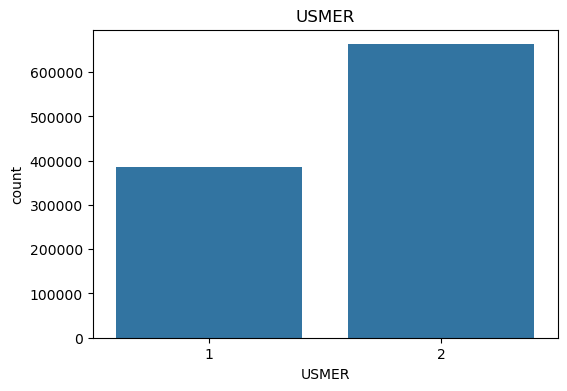

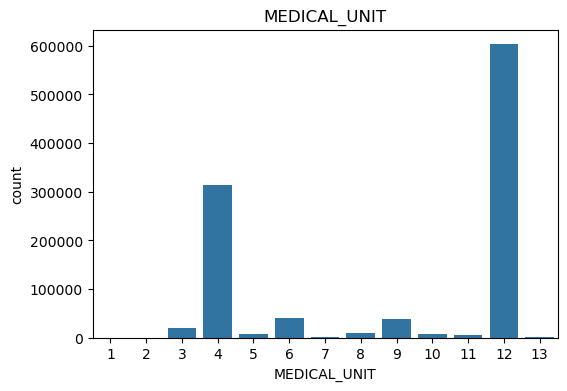

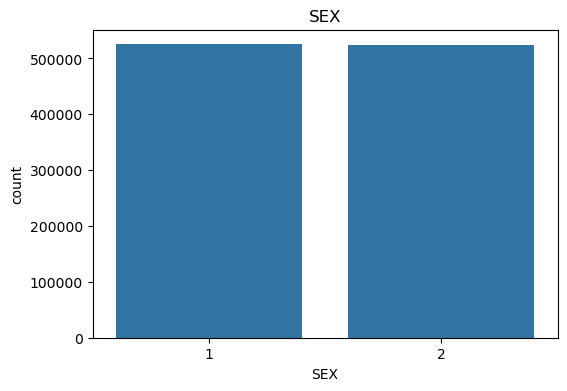

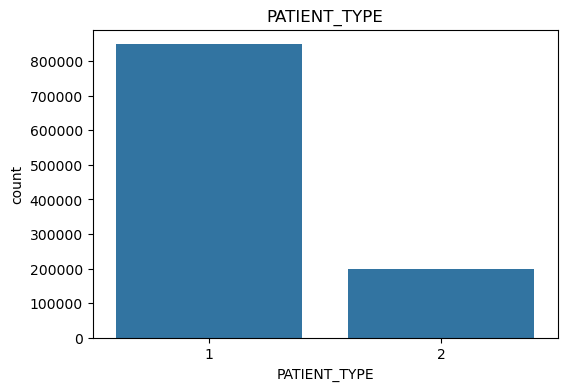

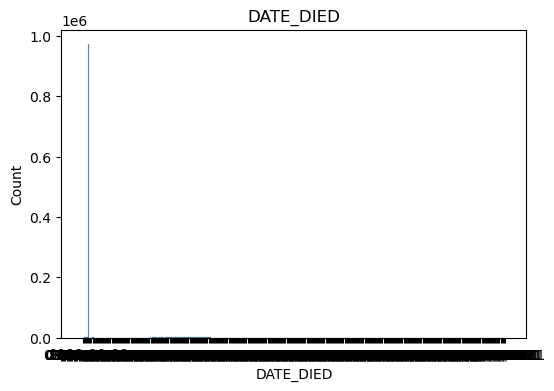

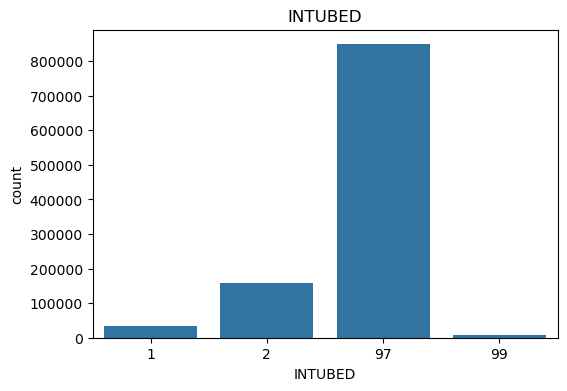

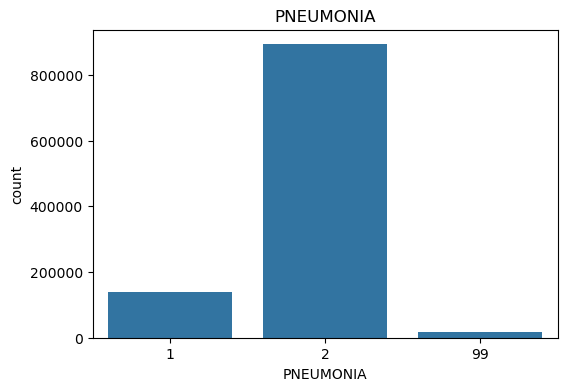

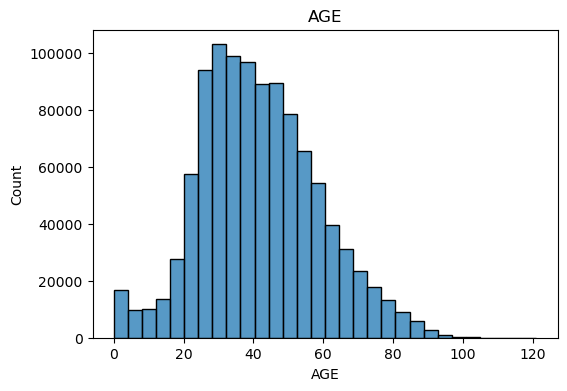

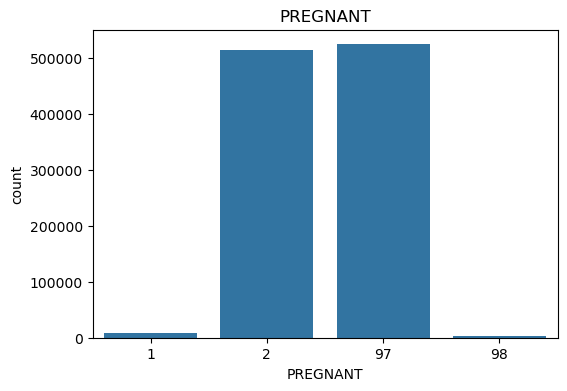

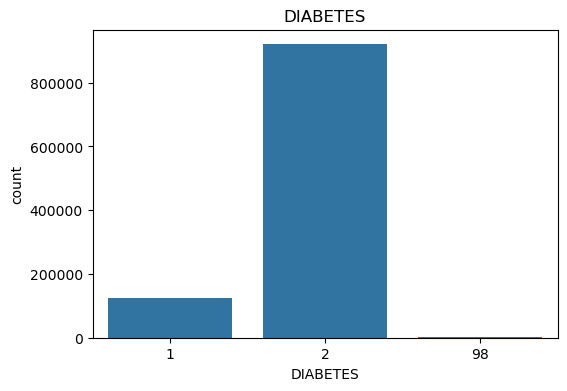

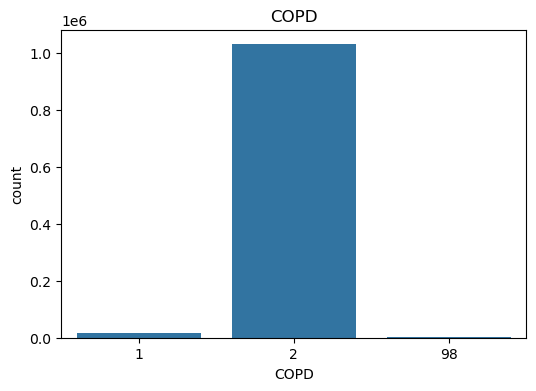

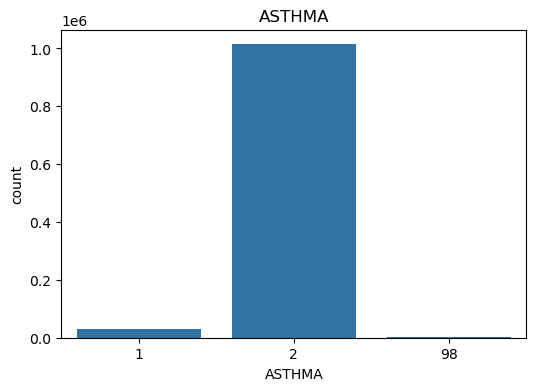

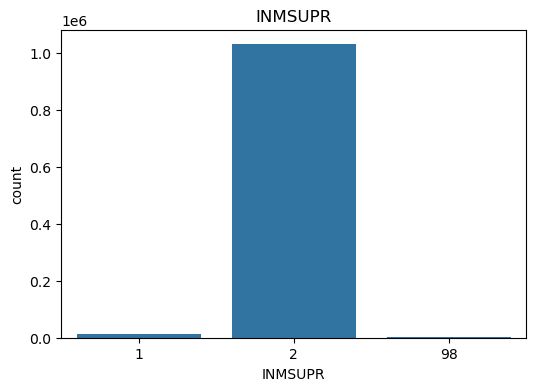

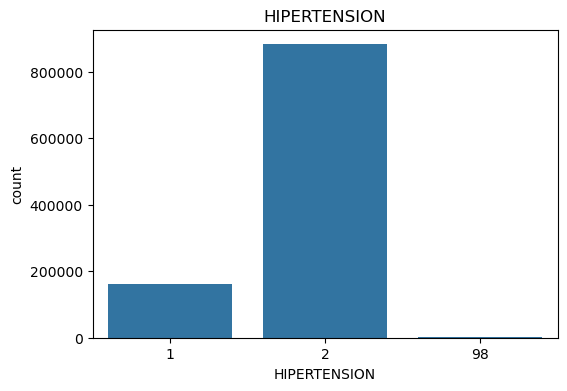

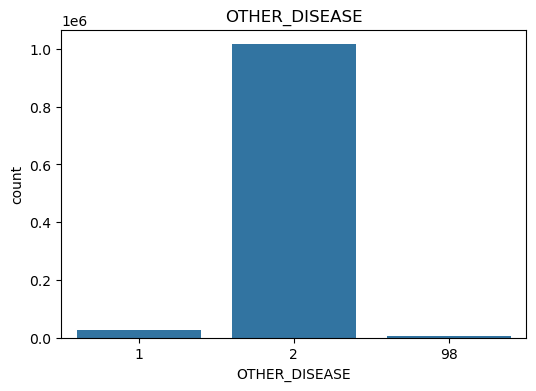

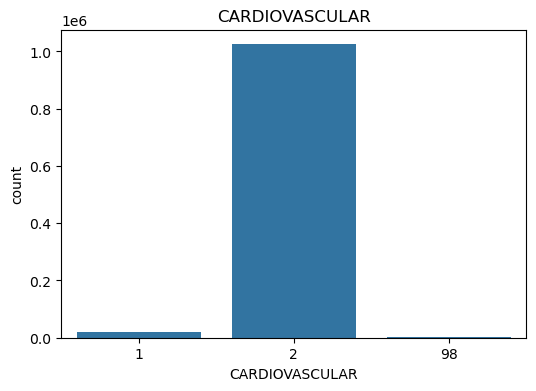

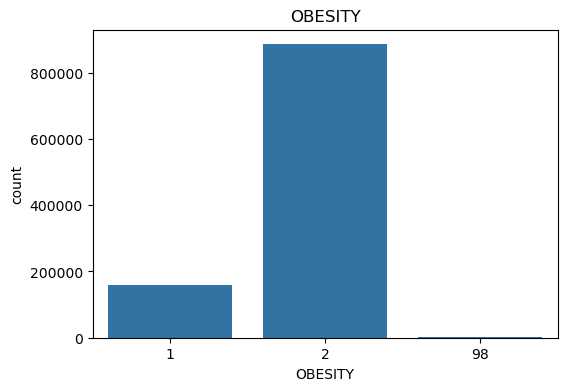

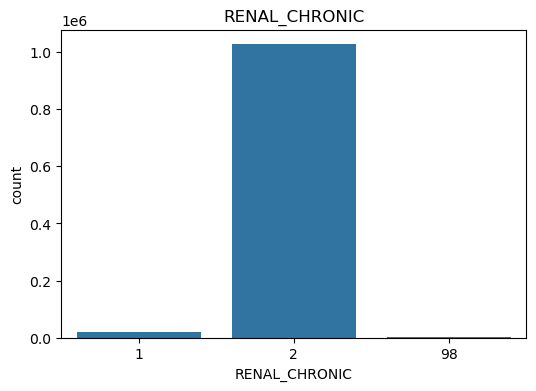

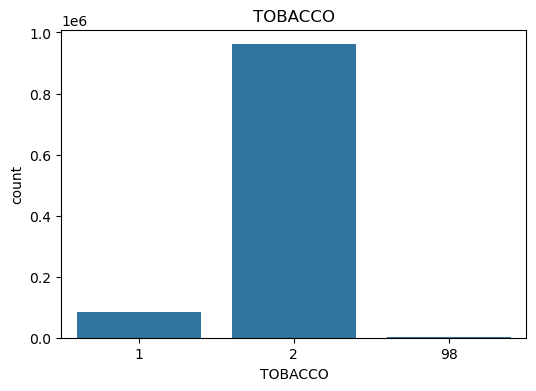

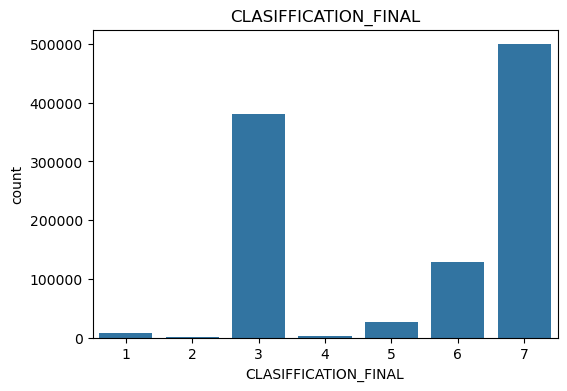

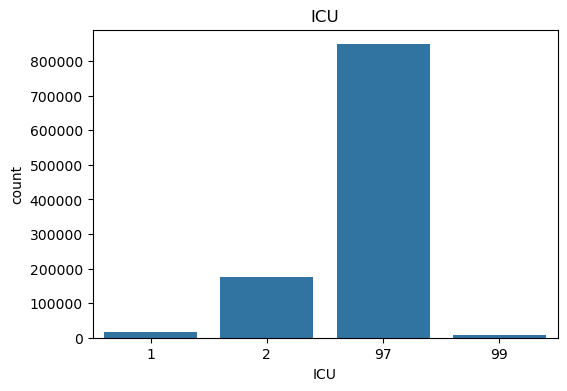

In [112]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in df.select_dtypes(include=['object', 'int', 'float']):
    plt.figure(figsize=(6, 4))
    if df[col].nunique() < 20:
        sns.countplot(data=df, x=col)
    else:
        sns.histplot(data=df, x=col, bins=30)
    plt.title(col)
    plt.show()

In [114]:
special_codes = [97, 98, 99]
df = df.replace(special_codes, np.nan)

bin_cols = [
    'USMER','MEDICAL_UNIT','SEX','PATIENT_TYPE','INTUBED','PNEUMONIA','PREGNANT',
    'DIABETES','COPD','ASTHMA','INMSUPR','HIPERTENSION','OTHER_DISEASE',
    'CARDIOVASCULAR','OBESITY','RENAL_CHRONIC','TOBACCO','ICU'
]
for c in [c for c in bin_cols if c in df.columns]:
    df[c] = df[c].map({1:1, 2:0})

In [116]:
df['survived'] = df['DATE_DIED'].apply(lambda x: 1 if x == "9999-99-99" else 0)

df['survived'].value_counts()


survived
1    971633
0     76942
Name: count, dtype: int64

In [118]:
print("Data types:\n", df.dtypes, "\n")

Data types:
 USMER                     int64
MEDICAL_UNIT            float64
SEX                       int64
PATIENT_TYPE              int64
DATE_DIED                object
INTUBED                 float64
PNEUMONIA               float64
AGE                     float64
PREGNANT                float64
DIABETES                float64
COPD                    float64
ASTHMA                  float64
INMSUPR                 float64
HIPERTENSION            float64
OTHER_DISEASE           float64
CARDIOVASCULAR          float64
OBESITY                 float64
RENAL_CHRONIC           float64
TOBACCO                 float64
CLASIFFICATION_FINAL      int64
ICU                     float64
survived                  int64
dtype: object 



In [154]:
features = [
    'USMER', 'MEDICAL_UNIT', 'SEX',
    'PNEUMONIA', 'AGE', 'PREGNANT', 'DIABETES', 'COPD', 'ASTHMA', 'INMSUPR',
    'HIPERTENSION', 'OTHER_DISEASE', 'CARDIOVASCULAR', 'OBESITY',
    'RENAL_CHRONIC', 'TOBACCO'
]

df_model = df[features + ['survived']].copy()


In [122]:
print("Data types:\n", df_model.dtypes, "\n")

Data types:
 USMER               int64
MEDICAL_UNIT      float64
SEX                 int64
PATIENT_TYPE        int64
PNEUMONIA         float64
AGE               float64
PREGNANT          float64
DIABETES          float64
COPD              float64
ASTHMA            float64
INMSUPR           float64
HIPERTENSION      float64
OTHER_DISEASE     float64
CARDIOVASCULAR    float64
OBESITY           float64
RENAL_CHRONIC     float64
TOBACCO           float64
survived            int64
dtype: object 



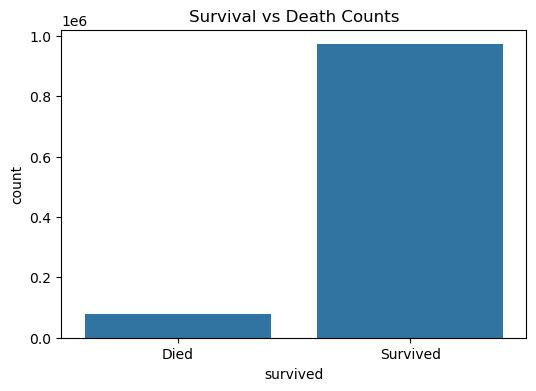

Overall survival rate: 92.66%


In [124]:
#Survival rate overview

plt.figure(figsize=(6,4))
sns.countplot(x='survived', data=df_model)
plt.title("Survival vs Death Counts")
plt.xticks([0,1], ['Died','Survived'])
plt.show()

survival_rate = df['survived'].mean()
print(f"Overall survival rate: {survival_rate:.2%}")


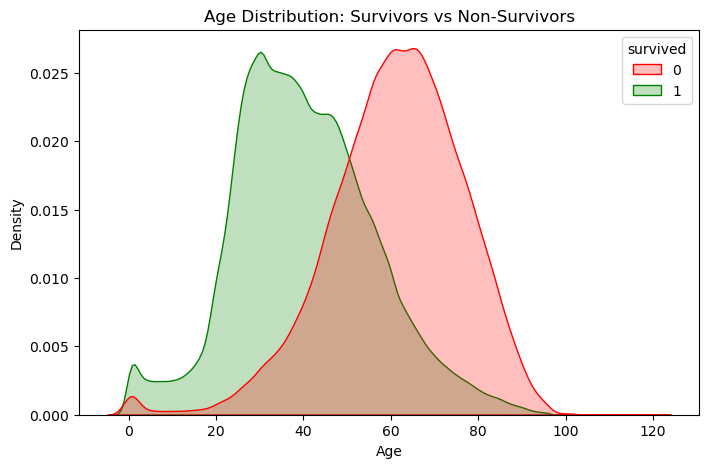

In [126]:
#Age distribution by survival

plt.figure(figsize=(8,5))
sns.kdeplot(data=df_model, x='AGE', hue='survived', fill=True, common_norm=False,
            palette=['red','green'])
plt.title("Age Distribution: Survivors vs Non-Survivors")
plt.xlabel("Age")
plt.ylabel("Density")
plt.show()


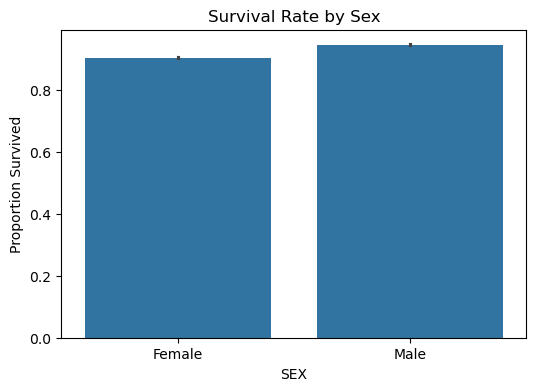

In [128]:
#Survival by sex

plt.figure(figsize=(6,4))
sns.barplot(x='SEX', y='survived', data=df_model)
plt.title("Survival Rate by Sex")
plt.xticks([0,1], ['Female','Male'])
plt.ylabel("Proportion Survived")
plt.show()


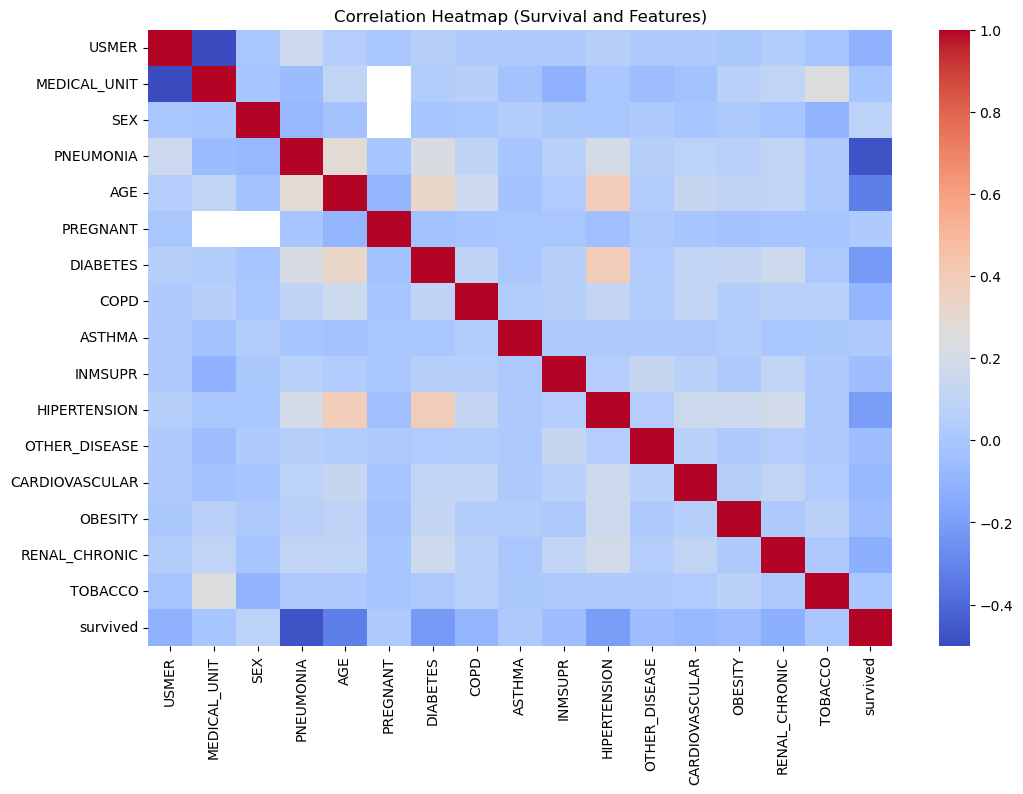

In [156]:
#Heatmap of correlations

plt.figure(figsize=(12,8))
sns.heatmap(df_model.corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap (Survival and Features)")
plt.show()


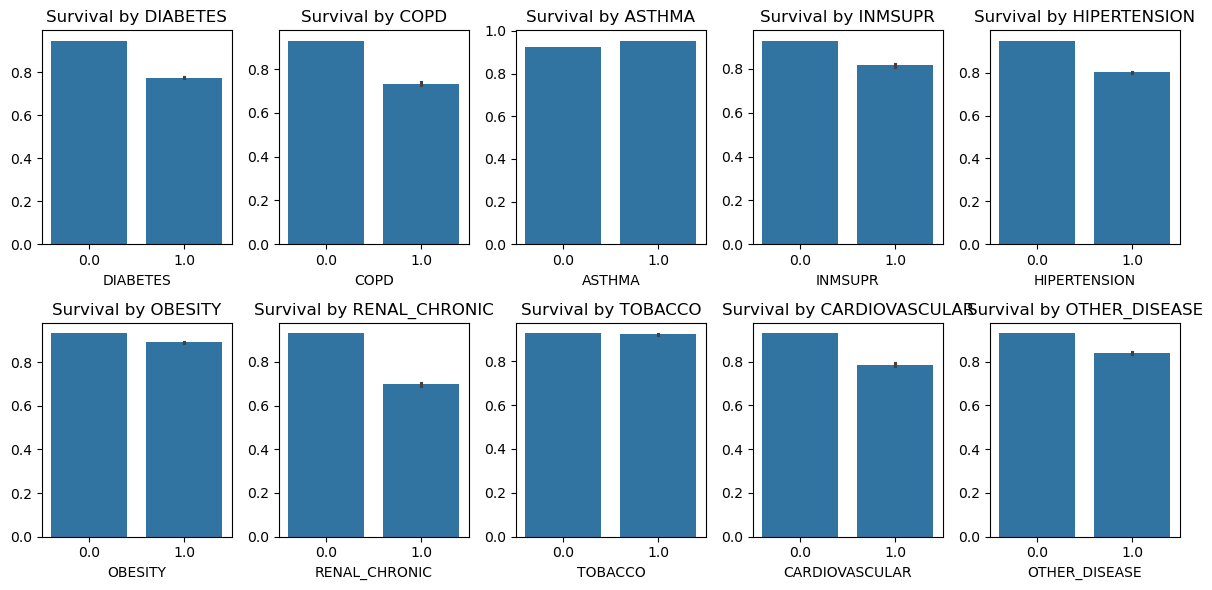

In [170]:
#Comorbidities vs. Survival (bar plots)

#comorbidities = ['DIABETES','COPD','ASTHMA','INMSUPR',
#                 'HIPERTENSION','OBESITY','RENAL_CHRONIC','TOBACCO']

comorbidities = [c for c in [
    'DIABETES','COPD','ASTHMA','INMSUPR','HIPERTENSION','OBESITY',
    'RENAL_CHRONIC','TOBACCO','CARDIOVASCULAR', 'OTHER_DISEASE'
] if c in df.columns]

df['comorbidity_count'] = df[comorbidities].fillna(0).sum(axis=1)


plt.figure(figsize=(12,6))
for i, col in enumerate(comorbidities, 1):
    plt.subplot(2,5,i)
    sns.barplot(x=col, y='survived', data=df_model)
    plt.title(f"Survival by {col}")
    plt.xlabel(col)
    plt.ylabel("")
plt.tight_layout()
plt.show()


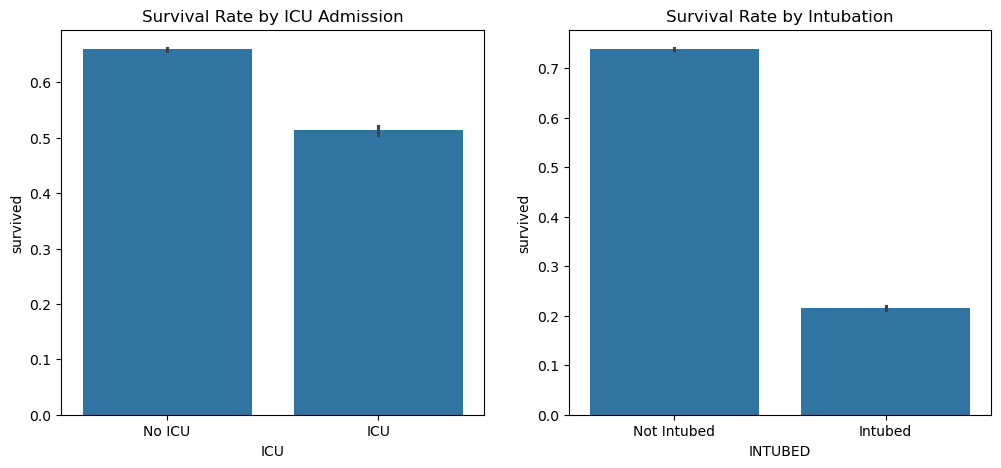

In [136]:
#ICU and intubation impact

fig, ax = plt.subplots(1, 2, figsize=(12,5))

sns.barplot(x='ICU', y='survived', data=df, ax=ax[0])
ax[0].set_title("Survival Rate by ICU Admission")
ax[0].set_xticks([0,1])
ax[0].set_xticklabels(['No ICU','ICU'])

sns.barplot(x='INTUBED', y='survived', data=df, ax=ax[1])
ax[1].set_title("Survival Rate by Intubation")
ax[1].set_xticks([0,1])
ax[1].set_xticklabels(['Not Intubed','Intubed'])

plt.show()


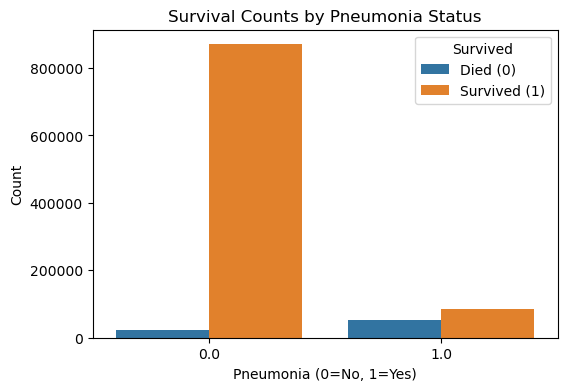

In [176]:
plt.figure(figsize=(6,4))
sns.countplot(x='PNEUMONIA', hue='survived', data=df)
plt.title("Survival Counts by Pneumonia Status")
plt.xlabel("Pneumonia (0=No, 1=Yes)")
plt.ylabel("Count")
plt.legend(title="Survived", labels=["Died (0)", "Survived (1)"])
plt.show()

PNEUMONIA
0.0    0.975032
1.0    0.614940
Name: survived, dtype: float64


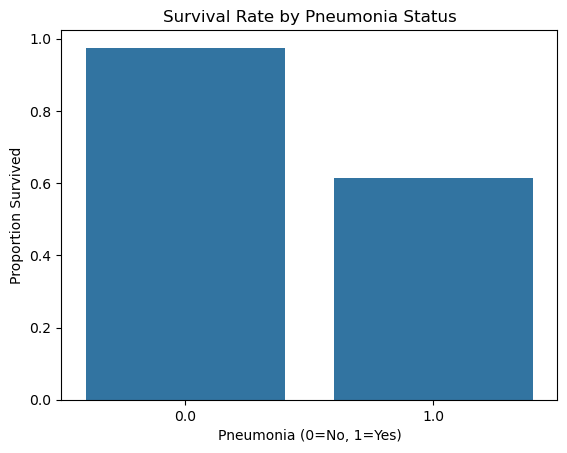

In [178]:
survival_rate = df.groupby('PNEUMONIA')['survived'].mean()
print(survival_rate)
sns.barplot(x=survival_rate.index, y=survival_rate.values)
plt.title("Survival Rate by Pneumonia Status")
plt.xlabel("Pneumonia (0=No, 1=Yes)")
plt.ylabel("Proportion Survived")
plt.show()

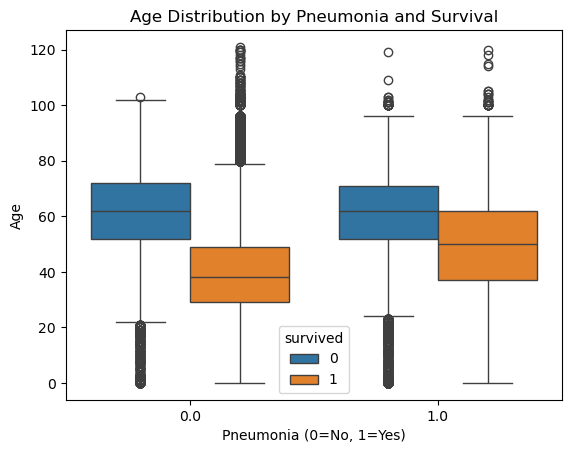

In [180]:
sns.boxplot(x='PNEUMONIA', y='AGE', hue='survived', data=df)
plt.title("Age Distribution by Pneumonia and Survival")
plt.xlabel("Pneumonia (0=No, 1=Yes)")
plt.ylabel("Age")
plt.show()

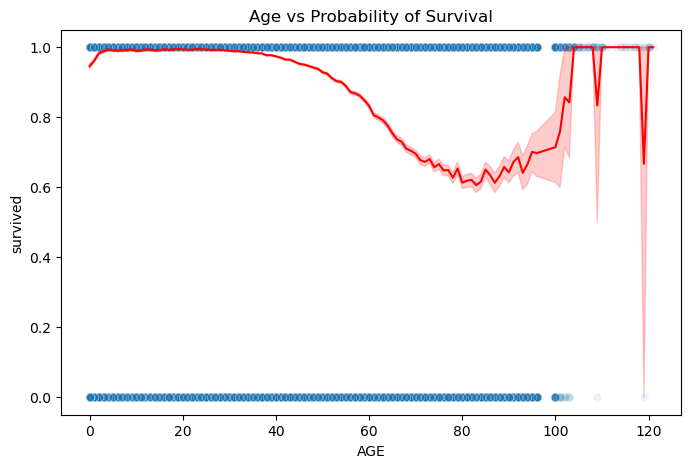

In [182]:
#Age vs. survial scatter/ trend

plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='AGE', y='survived', alpha=0.1)
sns.lineplot(data=df, x='AGE', y='survived', color='red')
plt.title("Age vs Probability of Survival")
plt.show()


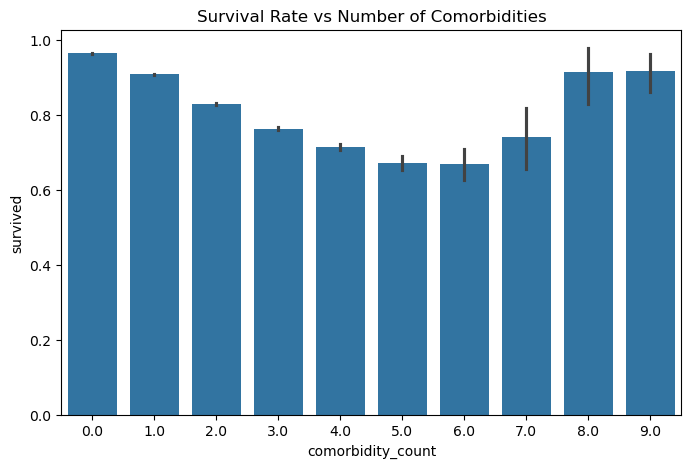

In [140]:
#Comorbidity count vs. Survival 

df['comorbidity_count'] = df[comorbidities].sum(axis=1)

plt.figure(figsize=(8,5))
sns.barplot(x='comorbidity_count', y='survived', data=df)
plt.title("Survival Rate vs Number of Comorbidities")
plt.show()


In [158]:
df_model.isna().sum()

USMER                   0
MEDICAL_UNIT      1048255
SEX                     0
PNEUMONIA           16003
AGE                   345
PREGNANT           527265
DIABETES             3338
COPD                 3003
ASTHMA               2979
INMSUPR              3404
HIPERTENSION         3104
OTHER_DISEASE        5045
CARDIOVASCULAR       3076
OBESITY              3032
RENAL_CHRONIC        3006
TOBACCO              3220
survived                0
dtype: int64

In [160]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
from sklearn.impute import SimpleImputer

X = df_model.drop("survived", axis=1)
y = df_model["survived"]

# Impute most-frequent for 0/1 columns; median for AGE if present
imp_mf = SimpleImputer(strategy='most_frequent')
X_imp = pd.DataFrame(imp_mf.fit_transform(X), columns=X.columns)

if 'AGE' in X_imp.columns:
    imp_age = SimpleImputer(strategy='median')
    X_imp[['AGE']] = imp_age.fit_transform(X_imp[['AGE']])

X_train, X_test, y_train, y_test = train_test_split(
    X_imp, y, test_size=0.2, random_state=42, stratify=y
)

logreg = LogisticRegression(max_iter=2000, class_weight='balanced')
logreg.fit(X_train, y_train)


LogisticRegression(class_weight='balanced', max_iter=2000)

In [162]:

y_pred = logreg.predict(X_test)
y_proba = logreg.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))


              precision    recall  f1-score   support

           0       0.33      0.84      0.48     15388
           1       0.99      0.87      0.92    194327

    accuracy                           0.86    209715
   macro avg       0.66      0.85      0.70    209715
weighted avg       0.94      0.86      0.89    209715

ROC AUC: 0.9214003608842594


In [164]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_proba_rf))


              precision    recall  f1-score   support

           0       0.31      0.76      0.44     15388
           1       0.98      0.87      0.92    194327

    accuracy                           0.86    209715
   macro avg       0.64      0.81      0.68    209715
weighted avg       0.93      0.86      0.88    209715

ROC AUC: 0.8786105557989118


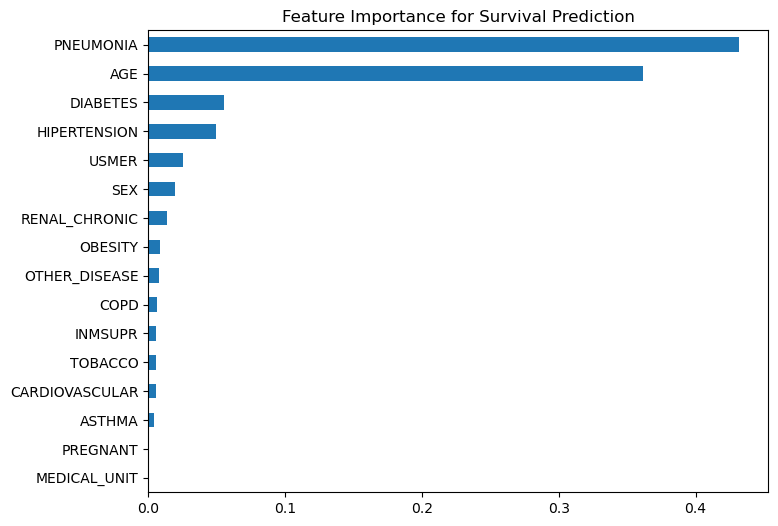

In [166]:
#Feature importance

importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values(ascending=True).plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance for Survival Prediction")
plt.show()


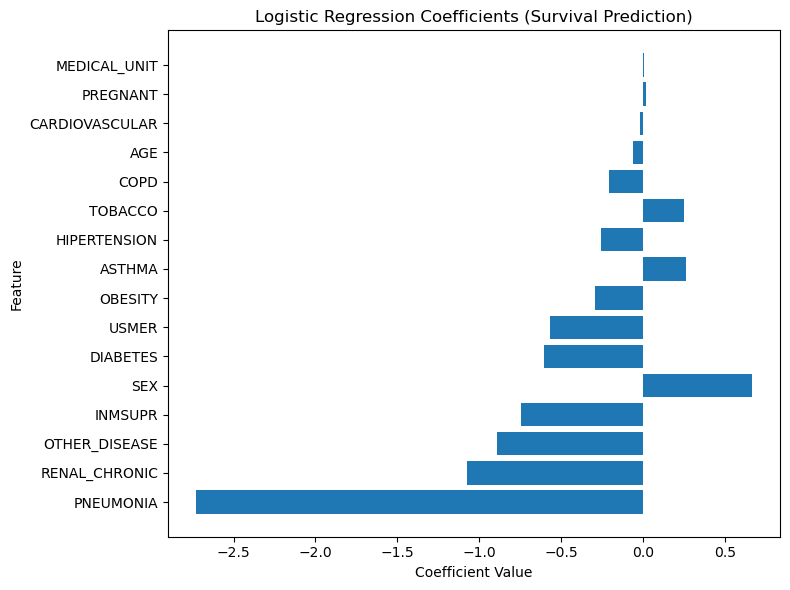

          Feature  Coefficient  Abs_Coefficient
3       PNEUMONIA    -2.730836         2.730836
14  RENAL_CHRONIC    -1.075933         1.075933
11  OTHER_DISEASE    -0.888922         0.888922
9         INMSUPR    -0.746100         0.746100
2             SEX     0.667105         0.667105
6        DIABETES    -0.601543         0.601543
0           USMER    -0.570470         0.570470
13        OBESITY    -0.289697         0.289697
8          ASTHMA     0.261186         0.261186
10   HIPERTENSION    -0.253436         0.253436


In [184]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': logreg.coef_[0],
    'Abs_Coefficient': abs(logreg.coef_[0])
}).sort_values('Abs_Coefficient', ascending=False)

plt.figure(figsize=(8,6))
plt.barh(coef_df['Feature'], coef_df['Coefficient'])
plt.title("Logistic Regression Coefficients (Survival Prediction)")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

print(coef_df.head(10))


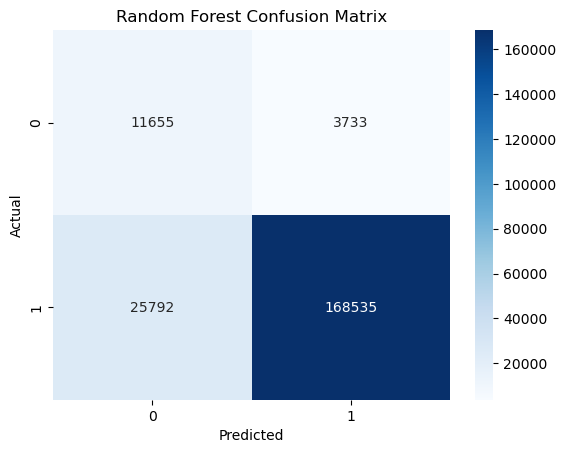

In [168]:
#Visualizing model preformance

cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()


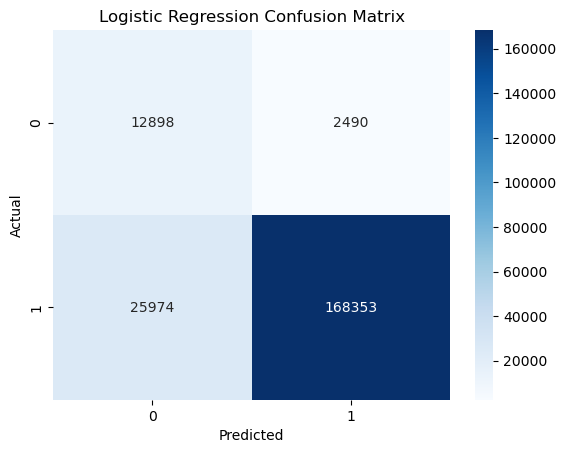

In [174]:
y_pred_lr = logreg.predict(X_test)

cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()